In [149]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Functions

In [334]:

def get_pv_mesh_from_atlas(bg_atlas, structure_name):
    """
    Get a PyVista mesh from the BrainGlobe Atlas for a given structure name.
    Args:
        bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
        structure_name (str): The name of the structure to retrieve.
    Returns:
        pv.PolyData: The PyVista mesh of the specified structure.
    """
    print(f"Selected structure {bg_atlas.structures[structure_name]['name']}")
    pv_brain_mesh   = pv.read(bg_atlas.structures[structure_name]['mesh_filename']) 

    return pv_brain_mesh


def add_brain_mesh(pv_brain_mesh, *,
                        plotter=None,
                        window_size= [800, 800],
                        notebook=True,
                        off_screen=False,
                        **kwargs):
    """
    Plot the PyVista mesh of a specified structure.
    Args:
        pv_brain_mesh (pv.PolyData): The PyVista mesh of the structure.
        plotter (pv.Plotter, optional): A PyVista plotter instance. If None, a new one will be created.
        plotter_args (dict, optional): Additional arguments for the plotter.
        **kwargs: Additional keyword arguments for the mesh rendering.
    Returns:
        pv.Plotter: The PyVista plotter with the mesh added.
    """
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size, 
                             off_screen=off_screen)
    default_kwargs = {
        'color': 'lightgrey',  # Default color for the mesh
        'opacity': 0.2,  # Default opacity for the mesh
        'label' : "Brain Region",  # label for the legend
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    plotter.add_mesh(pv_brain_mesh, **kwargs)
    return plotter

def add_doppler_vol(fUS_vol,*, 
                    plotter = None,
                    notebook = True,
                    window_size = [700,700],
                    off_screen=False,
                    **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        fUS_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
    	plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                             off_screen=off_screen)
    
    default_kwargs = {
        'scalars': 'BMODE',  # Assuming 'BMODE' is a scalar field in fUS_vol
        'cmap': 'hot',
        'opacity': 'sigmoid',
        'mapper': 'smart',
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
        },
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value
    
    vol=plotter.add_volume(fUS_vol, **kwargs)
    vol.prop.interpolation_type = 'linear'
    plotter.show_axes()
    plotter.show_grid()
    return plotter

def add_transducer_mesh(TX_mesh, *,
                        plotter=None,
                        window_size=[800, 800],
                        notebook=True,
                        off_screen=False,
                        **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    default_kwargs = {
        'scalars': 'Apodization',  # Assuming 'Apodization' is a scalar field in TX_mesh
        'cmap': 'cool',
        'clim': [0, 1],
        'opacity': 1.0,
        'show_edges': True,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Apodization',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.85,
            'position_y': 0.5,
            "height": 0.3,
        },
        'label' : "Transducer",  # label for the legend
        'color' : "purple", # color of the mesh
    }

    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value



    plotter.add_mesh(TX_mesh,   # Convert to mm for visualization
            **kwargs
        )
    return plotter

def add_pressure_vol(pressure_vol,*,
                    plotter=None,
                    window_size=[800, 800],
                    notebook=True,
                    plot_focal_spot = True,
                    off_screen=False,
                    **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    # 3) Add the pressure volume
    if plot_focal_spot:
        
        default_kwargs = {
            'opacity': 1,
            'name' : "PressureIso",
            'show_scalar_bar': False,
            'label': "Focal Spot",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value
                
        # pick a threshold, e.g. halfway to the max
        threshold = 0.7 * pressure_vol["Pressure"].max()
        iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
        plotter.add_mesh(iso_mesh, **kwargs)    

    else:
        n_contours = 10
        min_val = 0
        max_val = pressure_vol["Pressure"].max()
        levels = np.linspace(min_val, max_val, n_contours)
        iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
        default_kwargs = {
            'scalars': "Pressure",  # use the scalar to color surfaces
            'opacity': 'linear',
            'cmap' : "jet",
            'show_scalar_bar': True,
            'scalar_bar_args': {
                'title': 'Pressure (u.a.)',
                "title_font_size": 16,
                "label_font_size": 12,
                'vertical': True,
                'position_x': 0.85,
                'position_y': 0.2,
                "height": 0.3,
            },
            'label': "Pressure PII",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value

        plotter.add_mesh(iso_mesh, **kwargs)

    return plotter

# 2. Import data

In [ ]:
import h5py

gps_file = h5py.File(r"C:\Users\INSERM\Documents\Esteban\PySonoGen\src\pysonogen\datatype\Angio_angio3D.source.bps", "r")
file_scan_3D = h5py.File(r"C:\Users\INSERM\Documents\Esteban\PySonoGen\src\pysonogen\datatype\Angio_angio3D.source.scan", "r")

# Let's take the 008 scan. It shouwld be placed at one sagittal plane on the left side of the brain
# 

In [152]:
print("------gpsreg keys------")
print(gps_file.keys())
for key in gps_file.keys():
    print(f"{key}: {gps_file[key].shape} {gps_file[key].dtype}")

print("------scan_3D keys------")
print(file_scan_3D.keys())
for key in file_scan_3D.keys():
    print(f"{key}: {file_scan_3D[key]} ")

------gpsreg keys------
<KeysViewHDF5 ['BrainToLab', 'method', 'ref_name', 'score']>
BrainToLab: (4, 4) float64
method: () |S5
ref_name: () |S1
score: (1,) float64
------scan_3D keys------
<KeysViewHDF5 ['Data', 'acqMetaData', 'fileFormatVersion', 'fileID', 'scanMetaData', 'writingVersion']>
Data: <HDF5 dataset "Data": shape (41, 1, 163, 1, 128), type "<f8"> 
acqMetaData: <HDF5 group "/acqMetaData" (9 members)> 
fileFormatVersion: <HDF5 dataset "fileFormatVersion": shape (1, 1), type "<f8"> 
fileID: <HDF5 dataset "fileID": shape (1, 1), type "|O"> 
scanMetaData: <HDF5 group "/scanMetaData" (12 members)> 
writingVersion: <HDF5 dataset "writingVersion": shape (1, 1), type "<f8"> 


In [153]:
scan3D_data = file_scan_3D['Data'][()]
#If the space between the planes is small enough, we could treat
# each plane as slices and we discard the temporal information,
# we can then compute a 3D matrix with (x,y,z) information.
data3D_reshaped = scan3D_data.squeeze().transpose([2,0,1])
print("data3D_reshaped:", data3D_reshaped.shape)


data3D_reshaped: (128, 41, 163)


In [154]:
scan3D_metadata = file_scan_3D['acqMetaData']
print("\nscan3D_metadata:")
for key in scan3D_metadata.keys():
    print(f"{key}  : {scan3D_metadata[key]}")


scan3D_metadata:
acquisitionMode  : <HDF5 dataset "acquisitionMode": shape (1, 1), type "|O">
imgDim  : <HDF5 group "/acqMetaData/imgDim" (7 members)>
key7  : <HDF5 dataset "key7": shape (1, 1), type "|O">
probeToLab  : <HDF5 dataset "probeToLab": shape (41, 4, 4), type "<f8">
robotType  : <HDF5 dataset "robotType": shape (1, 1), type "|O">
time  : <HDF5 dataset "time": shape (41, 1), type "<f8">
timeOriginal  : <HDF5 dataset "timeOriginal": shape (41, 1), type "<f8">
voxDim  : <HDF5 group "/acqMetaData/voxDim" (4 members)>
voxelsToProbe  : <HDF5 dataset "voxelsToProbe": shape (4, 4), type "<f8">


# 2. qform : volxel -> Lab

In [354]:
time_vector = scan3D_metadata["imgDim"]

for key in time_vector.keys():
    print(f"{key}  : {time_vector[key][()]}")

dim7  : [[1.]]
nblockRepeat  : [[1.]]
npose  : [[41.]]
nscanRepeat  : [[1.]]
sizeX  : [[128.]]
sizeY  : [[1.]]
sizeZ  : [[163.]]


In [ ]:
voxelsToProbe3D = scan3D_metadata["voxelsToProbe"][()]
print("voxelsToProbe3D: \n", voxelsToProbe3D)
probeToLab3D = scan3D_metadata["probeToLab"][()]
print("probeToLab3D i = 0: \n", probeToLab3D[0])
print("probeToLab3D i = -1: \n", probeToLab3D[-1])
voxels2Lab3D = probeToLab3D[0].squeeze() @ voxelsToProbe3D *1e3 # Convert to mm  
invertz = np.diag([1, 1, -1, 1])  # Invert z-axis
qform = invertz @ voxels2Lab3D 
print("qform:\n", qform)

voxelsToProbe3D: 
 [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  2.00000e-04  0.00000e+00 -2.00000e-04]
 [ 0.00000e+00  0.00000e+00 -9.85600e-05 -4.90144e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]
probeToLab3D i = 0: 
 [[ 0.        1.        0.       -0.001301]
 [-1.        0.        0.        0.0075  ]
 [ 0.        0.        1.       -0.044198]
 [ 0.        0.        0.        1.      ]]
probeToLab3D i = -1: 
 [[ 0.        1.        0.        0.006699]
 [-1.        0.        0.        0.0075  ]
 [ 0.        0.        1.       -0.044198]
 [ 0.        0.        0.        1.      ]]
qform:
 [[ 0.000000e+00  2.000000e-01  0.000000e+00 -1.501000e+00]
 [-1.100000e-01  0.000000e+00  0.000000e+00  1.459500e+01]
 [ 0.000000e+00  0.000000e+00  9.856000e-02  4.909944e+01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+03]]


In [156]:
Bmode_dB = 20 * np.log10(np.abs(data3D_reshaped) / np.max(np.abs(data3D_reshaped)))
Bmode_dB = np.clip(Bmode_dB, -100, 0)

# Create the 3D UniformGrid
fUS_voxels = pv.ImageData(
    dimensions = Bmode_dB.shape
)

# Attach pressure data to the grid
fUS_voxels.point_data["BMODE"] = Bmode_dB.ravel(order="F")  # VERY important: Fortran order

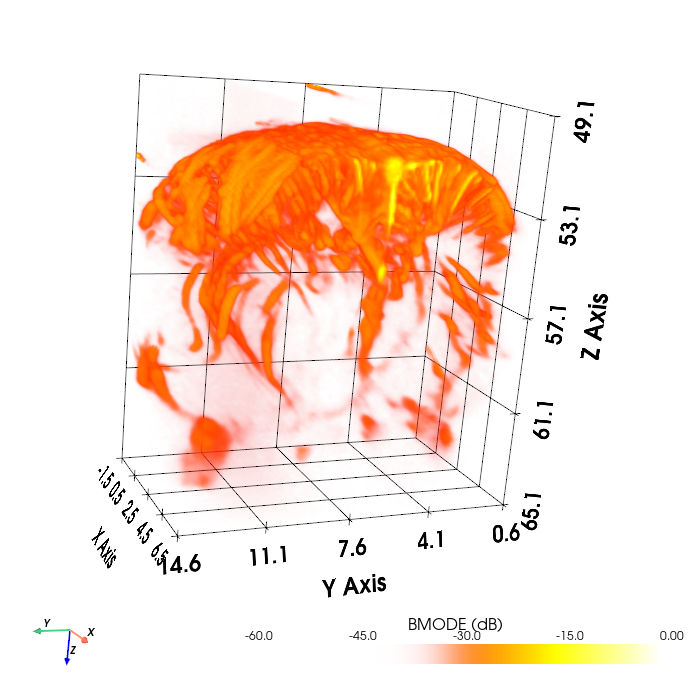

In [310]:
fUS_lab = fUS_voxels.copy()  #
fUS_lab.transform(qform, inplace=True)  # Apply the transformation to the image data

plotter_doppler = add_doppler_vol(fUS_lab, notebook=True, window_size=[700, 700], cmap="hot", opacity="sigmoid_15", clim=[-60, 0])
plotter_doppler.camera.up = (0, 0, -1)

plotter_doppler.camera_position = [(48.89292969166533, 28.644484315997296, 44.65937118460766),
 (2.9555144395554427, 6.590959412350619, 59.235767457999486),
 (-0.28786057558807776, -0.03299042999873854, -0.9571039235895962)]
plotter_doppler.show(jupyter_backend='static', title="Doppler Volume")

# 4. bg_atlas -> bps_atlas

In [174]:
from brainglobe_atlasapi import BrainGlobeAtlas
import brainglobe_space as bg_space

atlas_name = "whs_sd_rat_39um"
bg_atlas = BrainGlobeAtlas(atlas_name, check_latest=False)

region_name = "root" 

# Get the PyVista mesh for the specified structure
pv_brain_mesh = get_pv_mesh_from_atlas(bg_atlas, region_name)

# Now we create the target space 
target_space = bg_space.AnatomicalSpace("lpi") # New resolution to change the units from um to mm
trans_matrix_to_bps = bg_atlas.space.transformation_matrix_to(target_space)
print(trans_matrix_to_bps)

Selected structure Root
[[ 0.000e+00  0.000e+00 -1.000e+00  5.120e+02]
 [-1.000e+00  0.000e+00  0.000e+00  1.024e+03]
 [ 0.000e+00 -1.000e+00  0.000e+00  5.120e+02]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]


In [175]:
whs_origin_voxel = np.array([244, 623, 248])
bregma_voxel = np.array([246, 653, 440])
lambda_voxel = np.array([244, 442, 434])

resolution_um = np.array(bg_atlas.metadata['resolution']) # Convert to mm
resolution_mm = resolution_um*1e-3  # Convert to mm

resolution2Voxel =  np.diag(np.concatenate((1/resolution_um, [1])))  # Add a 1 for homogeneous coordinates
set_whs_origin = np.eye(4)
set_whs_origin[:3, 3] = -whs_origin_voxel

bregma2lambda_um = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_um[0])
bregma2lambda_mm = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_mm)
normalize_bregma2sigma_mm =  np.diag(np.concatenate(([resolution_mm[0]/bregma2lambda_mm]*3, [1])))  # Add a 1 for homogeneous coordinates
normalize_bregma2sigma_um =  np.diag(np.concatenate(([1/bregma2lambda_um]*3, [1])))  # Add a 1 for homogeneous coordinates

bregma2lambda_mm = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_mm)
print("Bregma to Lambda distance in mm:", bregma2lambda_mm)

bg_atlas2bps_atlas =  normalize_bregma2sigma_mm @ set_whs_origin @ trans_matrix_to_bps @ resolution2Voxel #@  # 
print("bg2atlas:\n", bg_atlas2bps_atlas)

Bregma to Lambda distance in mm: 8.232695852513926
bg2atlas:
 [[ 0.00000000e+00  0.00000000e+00 -1.21466895e-04  1.26957198e+00]
 [-1.21466895e-04  0.00000000e+00  0.00000000e+00  1.89962077e+00]
 [ 0.00000000e+00 -1.21466895e-04  0.00000000e+00  1.25062315e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [176]:
BrainToLab = gps_file["BrainToLab"][()]
print("BrainToLab:\n", BrainToLab)
Brain2Lab = BrainToLab * 1e3 # Convert to mm
Lab2Brain = np.linalg.inv(Brain2Lab)

bg_atlas2Lab = invertz @ Brain2Lab @ bg_atlas2bps_atlas

BrainToLab:
 [[-3.76735303e-05  8.79171079e-03 -1.07882876e-03  4.81839373e-03]
 [-8.85233911e-03  5.42178454e-19  3.09130494e-04  7.08612699e-03]
 [ 3.06826282e-04  1.07948635e-03  8.78635512e-03 -5.79131900e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [278]:

region1_name = "M1" 
region2_name = "S1-hl" 

# Get the PyVista mesh for the specified structure
pv_region1_mesh = get_pv_mesh_from_atlas(bg_atlas, region1_name)
pv_region2_mesh = get_pv_mesh_from_atlas(bg_atlas, region2_name)

Selected structure Primary motor area
Selected structure Primary somatosensory area, hindlimb representation


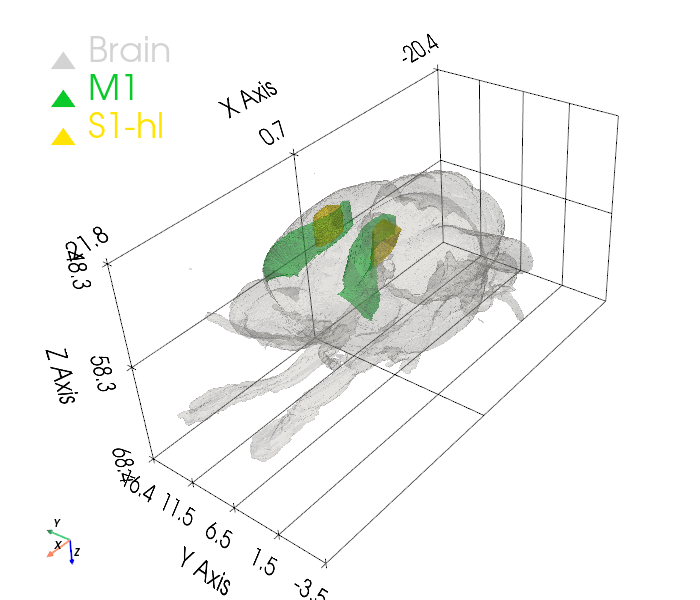

In [286]:
pv_brain_lab = pv_brain_mesh.copy()
pv_brain_lab .transform(bg_atlas2Lab, inplace=True)
pv_reg1_lab = pv_region1_mesh.copy()
pv_reg1_lab .transform(bg_atlas2Lab, inplace=True)
pv_reg2_lab = pv_region2_mesh.copy()
pv_reg2_lab .transform(bg_atlas2Lab, inplace=True)

plotter_brain = add_brain_mesh(pv_brain_lab,
                    window_size= [700, 600],
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)
plotter_brain = add_brain_mesh(pv_reg1_lab,
                            plotter=plotter_brain,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.4)
plotter_brain = add_brain_mesh(pv_reg2_lab,
                            plotter=plotter_brain,
                            color="cadmiumlemon", 
                            label = region2_name,
                            opacity=0.6)
plotter_brain.show_axes()
plotter_brain.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)
plotter_brain.add_legend(loc = 'upper left')             # show legend
plotter_brain.camera.up = (0, 0, -1)
plotter_brain.camera_position = [(62.38043351768633, -46.572019941797315, 3.3677604898116265),
 (3.550646527453603, 8.658160967847508, 59.16293041367433),
 (-0.47478103022555607, 0.32181283105475034, -0.8191577840114117)]  # Adjust camera position for better view
plotter_brain.show(jupyter_backend='static')

## 4.2. Going back to probe

In [382]:
print("voxelsToProbe3D:\n", voxelsToProbe3D)
print("probeToLab3D i=0:\n", probeToLab3D[0].squeeze())
print("qform:\n", qform)

voxelsToProbe3D:
 [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  2.00000e-04  0.00000e+00 -2.00000e-04]
 [ 0.00000e+00  0.00000e+00 -9.85600e-05 -4.90144e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]
probeToLab3D i=0:
 [[ 0.        1.        0.       -0.001301]
 [-1.        0.        0.        0.0075  ]
 [ 0.        0.        1.       -0.044198]
 [ 0.        0.        0.        1.      ]]
qform:
 [[ 0.000000e+00  2.000000e-01  0.000000e+00 -1.501000e+00]
 [-1.100000e-01  0.000000e+00  0.000000e+00  1.459500e+01]
 [ 0.000000e+00  0.000000e+00  9.856000e-02  4.909944e+01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+03]]


In [296]:
Probe2Lab = probeToLab3D[0].squeeze().copy()
Probe2Lab[:3,3] = Probe2Lab[:3,3]*1e3
Probe2Lab = invertz @ Probe2Lab  # Invert z-axis
print("Probe2Lab:\n", Probe2Lab)

Lab2Probe =  np.linalg.inv(Probe2Lab)
print("Lab2Probe:\n", Lab2Probe)

Probe2Lab:
 [[ 0.     1.     0.    -1.301]
 [-1.     0.     0.     7.5  ]
 [ 0.     0.    -1.    44.198]
 [ 0.     0.     0.     1.   ]]
Lab2Probe:
 [[-0.    -1.    -0.     7.5  ]
 [ 1.     0.     0.     1.301]
 [-0.    -0.    -1.    44.198]
 [ 0.     0.     0.     1.   ]]


In [371]:
aux = Lab2Probe[:3,:3] * Lab2Probe[:3,3][np.newaxis].T
aux

array([[ -0.   ,  -7.5  ,  -0.   ],
       [  1.301,   0.   ,   0.   ],
       [ -0.   ,  -0.   , -44.198]])

In [389]:
translation = np.array([0,0,Lab2Probe[2,3]])  # Compute the translation vector
translation

array([ 0.   ,  0.   , 44.198])

In [ ]:
fUS_probe = fUS_lab.copy()
fUS_probe.translate(-translation, inplace=True)  # Transform to Probe coordinates
pv_brain_probe = pv_brain_lab.copy()
pv_brain_probe.translate(-translation, inplace=True)  # Transform to Probe coordinates

pv_reg1_probe = pv_reg1_lab.copy()
pv_reg1_probe.translate(-translation, inplace=True)
pv_reg2_probe = pv_reg2_lab.copy()
pv_reg2_probe .translate(-translation, inplace=True)

PolyData (0x190a5ccef20)
  N Cells:    16398
  N Points:   8203
  N Strips:   0
  X Bounds:   2.259e+00, 5.177e+00
  Y Bounds:   3.210e+00, 1.159e+01
  Z Bounds:   6.174e+00, 9.364e+00
  N Arrays:   1

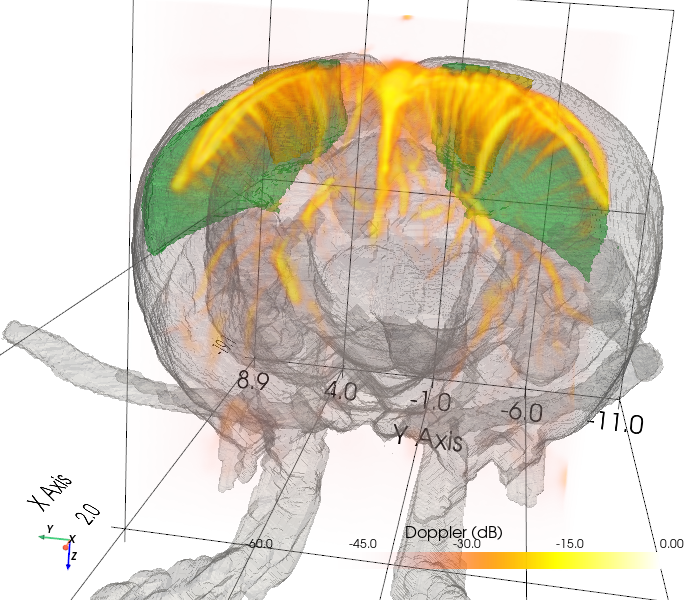

In [378]:


plotter_atlas_dopper = add_brain_mesh(pv_brain_probe,
                    window_size= [700, 600],
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

plotter_atlas_dopper = add_doppler_vol(fUS_probe,
                        plotter=plotter_atlas_dopper,
                        cmap="hot", 
                        opacity="sigmoid", 
                        opacity_unit_distance = 5,
                        clim=[-60, 0])


plotter_atlas_dopper = add_brain_mesh(pv_reg1_probe,
                            plotter=plotter_atlas_dopper,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.4)
plotter_atlas_dopper = add_brain_mesh(pv_reg2_probe,
                            plotter=plotter_atlas_dopper,
                            color="cadmiumlemon", 
                            label = region2_name,
                            opacity=0.6)


plotter_atlas_dopper.camera.up = (0, 0, -1)
plotter_atlas_dopper.camera_position = [(38.69889107943288, -3.754290905852268, 4.29164624069747),
 (2.534256310783335, 0.9981280056981565, 14.298747329233452),
 (-0.25258506690569976, 0.10359277324938992, -0.9620131606723182)]

plotter_atlas_dopper.show_axes()
plotter_atlas_dopper.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)

plotter_atlas_dopper.show(jupyter_backend='static')


In [322]:
plotter_atlas_dopper.camera_position

[(38.69889107943288, -3.754290905852268, 4.29164624069747),
 (2.534256310783335, 0.9981280056981565, 14.298747329233452),
 (-0.25258506690569976, 0.10359277324938992, -0.9620131606723182)]

# Compute of pressure field

In [257]:
# Create transducer with elevation focus
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)


['LinearArrayTransducer', 'MatrixArrayTransducer']
Transducer initialized in 0.0169 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


Successfully initialized PyField with 
 LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=rect, tx_N_active=38, F_over_D=2)
Focus: 1.150 mm, 0.000 mm, 8.200 mm


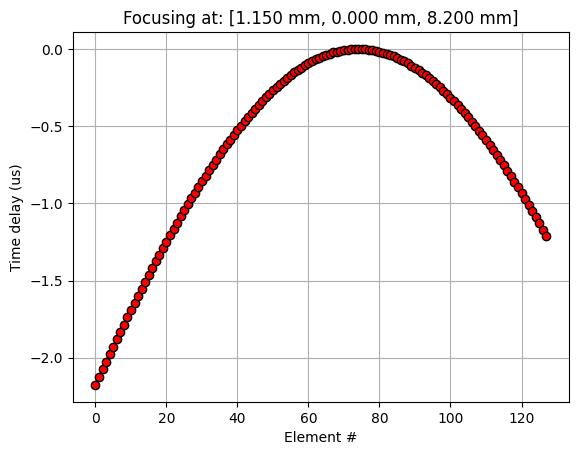

Focus: 1.150 mm, 0.000 mm, 8.200 mm


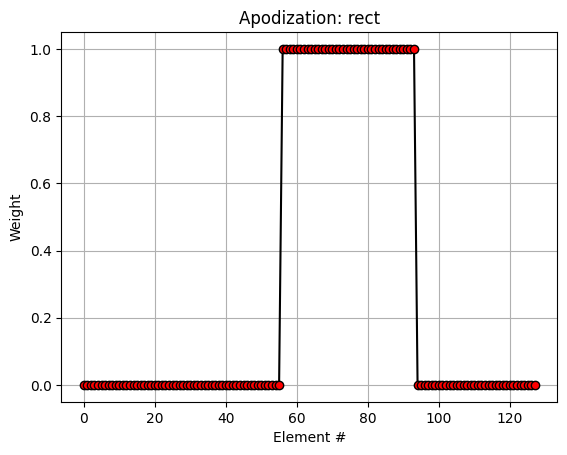

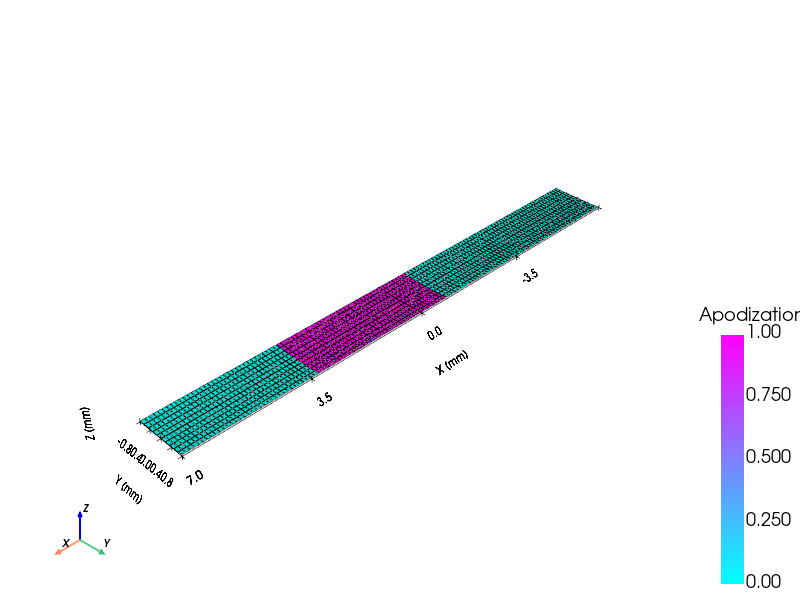

In [269]:
import pysonogen
from pysonogen import pyfield
Domino_field = pyfield.PyField(domino)

# Focalization spot
focus_mm =  np.array([1.15, 0, 8.2])  # mm [x, y, z]
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 2, apodization_type='rect', plot = True)
domino.show(jupyter_backend='static')
TX_mesh = domino.get_mesh()


In [262]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}
pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)

Creating simulation grid...
Computing spatial impulse response...
Computing SIR for 68921 points and 1280 patches...
Computing all patch events...
Accumulating SIR from events...
Total computation time: 17.8525 seconds.
Computing pressure field...
Original h shape: (512, 68921)
Reshaped h shape: (512, 41, 41, 41)
Performing FFT...
Frequency searched: 12500000.0 Hz. Found: 12328767.123287672 Hz


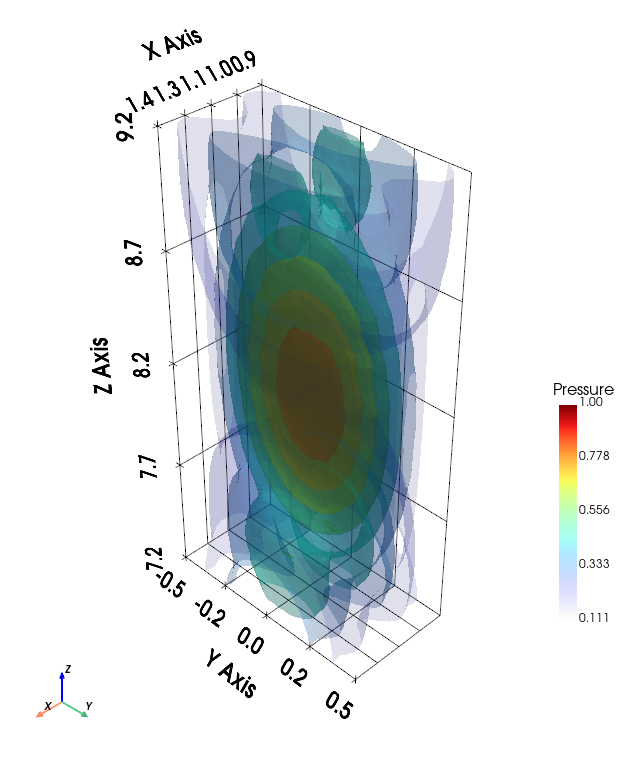

In [270]:
pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 780])

pressure_plotter.show(jupyter_backend='static')  # Add this parameter

# 5. Plot brain and pressure field

In [402]:
TX_mesh_lab = TX_mesh.copy()
invertx = np.diag([-1, 1, 1, 1])  # Invert y-axis
TX2Lab =  Probe2Lab
TX_mesh_lab.transform(TX2Lab, inplace=True)  # Transform to Lab coordinates

PolyData (0x19202b51540)
  N Cells:    1280
  N Points:   5120
  N Strips:   0
  X Bounds:   -2.051e+00, -5.510e-01
  Y Bounds:   4.610e-01, 1.454e+01
  Z Bounds:   4.416e+01, 4.420e+01
  N Arrays:   1

In [403]:
final_plotter = add_brain_mesh(pv_brain_lab,
                    window_size= [1080, 960],
                    notebook=False,
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

final_plotter = add_doppler_vol(fUS_lab,
                        plotter=final_plotter,
                        cmap="hot", 
                        opacity="sigmoid", 
                        opacity_unit_distance = 5,
                        clim=[-60, 0])


final_plotter = add_brain_mesh(pv_reg1_lab,
                            plotter=final_plotter,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.4)

final_plotter = add_brain_mesh(pv_reg2_lab,
                            plotter=final_plotter,
                            color="blue", 
                            label = region2_name,
                            opacity=0.6)

final_plotter = add_transducer_mesh(TX_mesh_lab,
                        plotter=final_plotter, show_edges=False)


final_plotter.camera.up = (0, 0, -1)
final_plotter.show_axes()
final_plotter.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)

final_plotter.add_legend(loc = 'upper left')             # show legend
final_plotter.show() # ,

In [391]:
final_plotter = add_brain_mesh(pv_brain_probe,
                    window_size= [1080, 960],
                    notebook=False,
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

final_plotter = add_doppler_vol(fUS_probe,
                        plotter=final_plotter,
                        cmap="hot", 
                        opacity="sigmoid", 
                        opacity_unit_distance = 5,
                        clim=[-60, 0])


final_plotter = add_brain_mesh(pv_reg1_probe,
                            plotter=final_plotter,
                            color="permanentgreen", 
                            label = region1_name,
                            opacity=0.4)

final_plotter = add_brain_mesh(pv_reg2_probe,
                            plotter=final_plotter,
                            color="blue", 
                            label = region2_name,
                            opacity=0.6)

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False)

final_plotter = add_pressure_vol(pressure_vol_mesh,
                        plotter=final_plotter,
                        plot_focal_spot=True)

final_plotter.camera.up = (0, 0, -1)
final_plotter.camera_position = [(67.95392466413932, -0.6249611748695701, -13.191532202673908),
 (3.8237745557155436, -1.4869571558041679, 13.112628093230912),
 (-0.37954974503079236, 0.0060970103961559925, -0.9251512403446744)]
final_plotter.show_axes()
final_plotter.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)

final_plotter.add_legend(loc = 'upper left')             # show legend
final_plotter.show() # ,

In [333]:
final_plotter.camera_position

[(67.95392466413932, -0.6249611748695701, -13.191532202673908),
 (3.8237745557155436, -1.4869571558041679, 13.112628093230912),
 (-0.37954974503079236, 0.0060970103961559925, -0.9251512403446744)]

In [340]:
make_movie = False

if make_movie:

    video_plotter = add_brain_mesh(pv_brain_probe,
                    window_size= [1080, 960],
                    notebook=True,
                    off_screen=True,
                    color="lightgray", 
                    label = "Brain",
                    opacity=0.2)

    video_plotter = add_doppler_vol(fUS_probe,
                            plotter=video_plotter,
                            cmap="hot", 
                            opacity="sigmoid", 
                            opacity_unit_distance = 5,
                            clim=[-60, 0])


    video_plotter = add_brain_mesh(pv_reg1_probe,
                                plotter=video_plotter,
                                color="permanentgreen", 
                                label = region1_name,
                                opacity=0.4)

    video_plotter = add_brain_mesh(pv_reg2_probe,
                                plotter=video_plotter,
                                color="blue", 
                                label = region2_name,
                                opacity=0.6)

    video_plotter = add_transducer_mesh(TX_mesh,
                            plotter=video_plotter, show_edges=False)

    video_plotter = add_pressure_vol(pressure_vol_mesh,
                            plotter=video_plotter,
                            plot_focal_spot=True)

    video_plotter.camera.up = (0, 0, -1)
    video_plotter.camera_position = [(67.95392466413932, -0.6249611748695701, -13.191532202673908),
    (3.8237745557155436, -1.4869571558041679, 13.112628093230912),
    (-0.37954974503079236, 0.0060970103961559925, -0.9251512403446744)]
    video_plotter.show_axes()
    video_plotter.show_grid(
        bold =False, n_zlabels = 3, n_xlabels = 3
    )

    video_plotter.add_legend(loc = 'upper left')             # show legend


    # Render once before movie to apply camera and settings
    video_plotter.render()

    # Open movie file and define frame settings
    n_frames = 180
    video_filename = "sonogen_experiment.mp4"
    video_plotter.open_movie(video_filename, framerate=20)

    # Rotation loop
    video_plotter.show(auto_close=False)

    delta_angle_deg = 360 / n_frames
    angle_deg = 0 
    for i in range(n_frames):
        angle_deg += 2
        video_plotter.camera.azimuth = angle_deg # Rotate camera
        video_plotter.render()
        video_plotter.write_frame()

    # Finalize and save
    video_plotter.close()
    print(f" Video saved to: {video_filename}")